# Programación para la Bioinformática

Unidad 3: Librerías científicas en Python - Matplotlib - Ejercicios
------------------------------------------------------

## Etiquetas

Bienvenidos a la PEC de la unidad 3. Bajo estas lineas encontrareis ejercicios y preguntas cada uno de ellos tendrá una etiqueta que indica los recursos necesarios para resolverlos. Hay tres posibles etiquetas:



* **<font color="green" size="+2">MU</font>** **Materiales unidad**: las herramientas necesarias para realizar la actividad se pueden encontrar en los materiales de la asignatura.

* **<font color="blue" size="+2">EG</font>** **Consulta externa guiada**: la actividad puede requerir utilizar herramientas que no se encuentran en los materiales de la asignatura, pero el enunciado contiene indicaciones de como encontrar la información adicional necesaria.

* **<font color="gold" size="+2">CI</font>** **Consulta externa independiente**: la actividad puede requerir utilizar herramientas que no se encuentran en los materiales de la asignatura, y el enunciado no incluye las indicaciones de como encontrar la información adicional. El estudiante deberá buscar esta información independientemente.

## Tests

Antes de nada, decir que en el ámbito de la programación es muy común utilizar tests (llamados tests unitarios) durante la codificación de los programas. Los tests sirven para saber si un programa se comporta como se espera. Es decir, sirven para validar la funcionalidad del programa, no para determinar la calidad del código.

Así pues, los tests son un gran aliado del programador. Es por eso que la mayoría de los ejercicios e incluso alguna de las preguntas tendran una celda bajo ellas con un comentario en la primera línea con el título: `# Test Ejercicio X` o `Test Pregunta X`

**IMPORTANTE**: **no debéis modificar las celdas de test**.

Si las ejecutáis, lo que CoLab hará será ejecutar el test correspondiente sobre vuestro código. Dependiendo del resultado, sabréis que:

* Si el test falla, entonces vuestro código no funciona como se espera. Así pues, tendréis que corregirlo.

* Si el test no falla, entonces vuestro código se comporta como se espera. Sin embargo, esto no significa que el el ejercicio sea correcto, ya que hay situaciones en las que se pide usar una determinada función o estructura. Por ejemplo, imaginad que se pide resolver un ejercicio usando un ``for`` y, en su lugar, usáis un ``while``. Pues seguramente vuestro programa pasaría el test (porque funciona como se espera), pero no respeta un requisito del enunciado.

**Para poder ejecutar los tests primero debéis ejecutar la siguiente celda de código**: (Tan solo una vez por sesión)

In [1]:
#!pip install ipytest
import ipytest
ipytest.autoconfig()

### **Ejercicios de entrenamiento**

### **Ejercicicio 1**


Haced un gráfico en el que se vea la progresión del rmsd a lo largo del tiempo, de los pasos de una dinámica molecular. Los valores de RMSD y los pasos de tiempo se encuentran en el fichero msd_uoc.dat. La primera columna corresponde a los pasos de tiempo, la segunda al backbone de la proteina, la tercera al substrato y la cuarta al centro activo.

El gráfico tiene que tener definido:

* Titulo en el eje x e y (con un tamaño de la letra de 14)
* Leyenda
* Cambiáis los colores predeterminados para cada columna dibujada

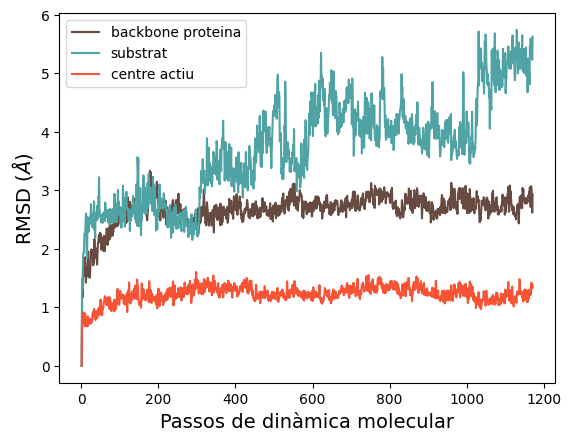

In [ ]:
# Ejecutad primero esta celda para obtener el fichero
!wget -nc https://gitlab.uoclabs.uoc.es/prog_bioinf/data/-/raw/master/Unidad3/rmsd_uoc.dat --no-check-certificate

--2024-04-15 20:59:40--  https://gitlab.uoclabs.uoc.es/prog_bioinf/data/-/raw/master/Unidad3/rmsd_uoc.dat
Resolving gitlab.uoclabs.uoc.es (gitlab.uoclabs.uoc.es)... 18.201.253.30
Connecting to gitlab.uoclabs.uoc.es (gitlab.uoclabs.uoc.es)|18.201.253.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 69810 (68K) [text/plain]
Saving to: ‘rmsd_uoc.dat’

rmsd_uoc.dat        100%[===================>]  68.17K   144KB/s    in 0.5s    

2024-04-15 20:59:41 (144 KB/s) - ‘rmsd_uoc.dat’ saved [69810/69810]



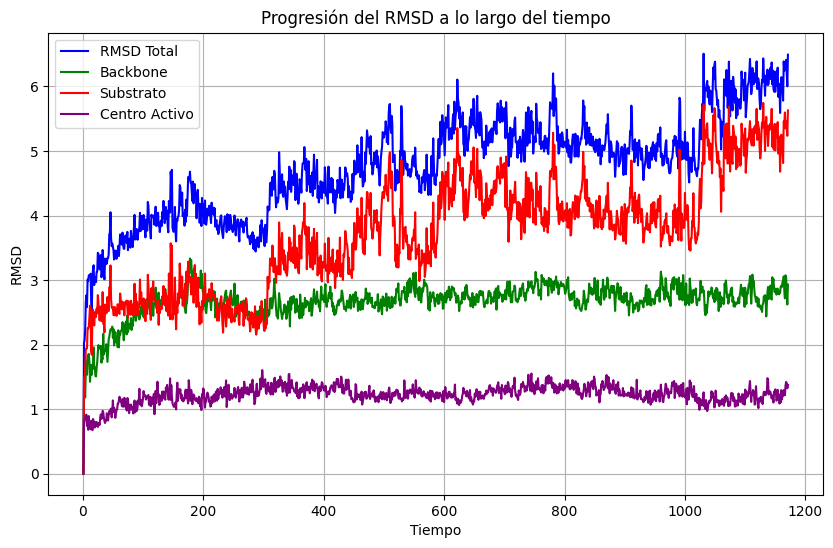

In [52]:
# para poder visualizar el grafico en este notebook
%matplotlib inline

# importamos los módulos necesarios
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

#RESPUESTA

# Leer datos del archivo
data = np.loadtxt('rmsd_uoc.dat.txt')

# Extraer pasos de tiempo y valores RMSD para cada componente
pasos_tiempo = data[:, 0]
rmsd_backbone = data[:, 1]
rmsd_substrato = data[:, 2]
rmsd_centro_activo = data[:, 3]

# Calcular RMSD total como la suma de las tres componentes
rmsd_total = np.sqrt(rmsd_backbone**2 + rmsd_substrato**2 + rmsd_centro_activo**2)

# Crear gráfico
plt.figure(figsize=(10, 6))
plt.plot(pasos_tiempo, rmsd_total, label='RMSD Total', color='blue')
plt.plot(pasos_tiempo, rmsd_backbone, label='Backbone', color='green')
plt.plot(pasos_tiempo, rmsd_substrato, label='Substrato', color='red')
plt.plot(pasos_tiempo, rmsd_centro_activo, label='Centro Activo', color='purple')

plt.title('Progresión del RMSD a lo largo del tiempo')
plt.xlabel('Tiempo')
plt.ylabel('RMSD')
plt.legend()
plt.grid(True)

plt.show()


### **Ejercicicio 2**

Haced un gráfico en que se vea el rmsd del backbone de la proteína y el del centro activo en forma de histograma a lo largo de la trayectoria. El gráfico tiene que cumplir las siguientes condiciones:

* Tenéis que tener dos subplots por cada sistema.
* Los dos subplots tienen que compartir el mismo eje de las y
* Lo primero plot tiene que tener transparencia y tiene que ser de color verde rellenado
* El segundo plot solo tiene que tener la línea del histograma de color rojol

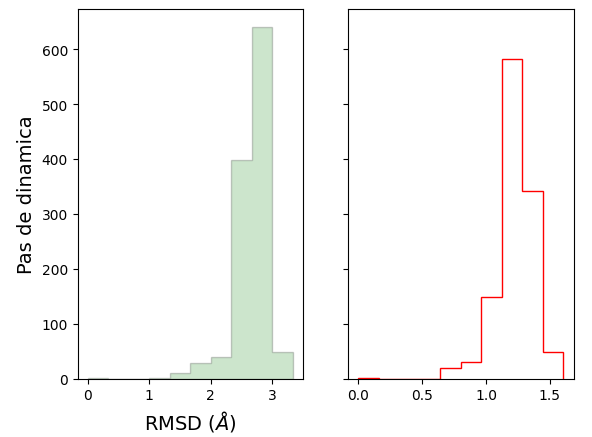


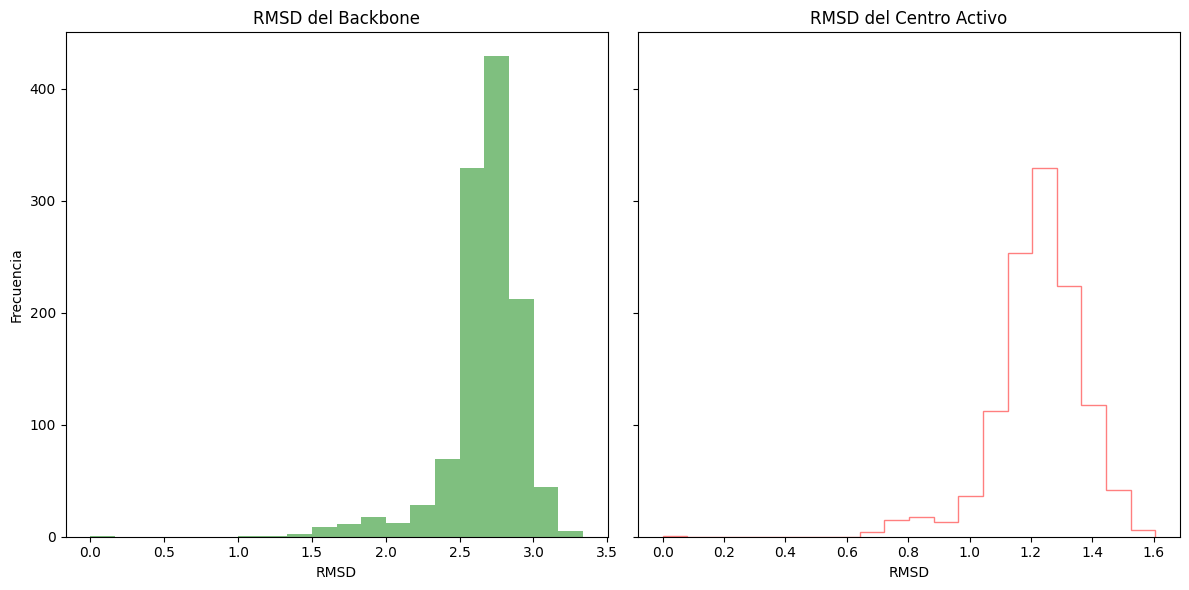

In [18]:
# para poder visualizar el grafico en este notebook
%matplotlib inline

#RESPUESTA
import numpy as np
import matplotlib.pyplot as plt

# Leer datos del archivo
data = np.loadtxt('rmsd_uoc.dat.txt')

# Extraer pasos de tiempo y valores RMSD para backbone y centro activo
pasos_tiempo = data[:, 0]
rmsd_backbone = data[:, 1]
rmsd_centro_activo = data[:, 3]

# Crear figura y ejes
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 6))

# Histograma del RMSD del backbone
axs[0].hist(rmsd_backbone, bins=20, color='green', alpha=0.5)
axs[0].set_ylabel('Frecuencia')
axs[0].set_xlabel('RMSD')
axs[0].set_title('RMSD del Backbone')

# Histograma del RMSD del centro activo
axs[1].hist(rmsd_centro_activo, bins=20, color='red', alpha=0.5, histtype='step')
axs[1].set_xlabel('RMSD')
axs[1].set_title('RMSD del Centro Activo')

# Ajuste de diseño
plt.tight_layout()

# Mostrar gráfico
plt.show()


### **Ejercicicio 3**



Existen una gran variedad de base de datos para todos los tipos de sistemas biológicos en que estemos interesados. Una de ellas es la base de datos llamada **CAZy** (http://www.cazy.org/), en que podemos encontrar descritas todas las familias de módulos catalíticos y de unión de carbohidratos relacionados estructuralmente (o dominios funcionales) de enzimas que degradan, modifican o crean enlaces glicosídicos, denominados **CAZymes**.

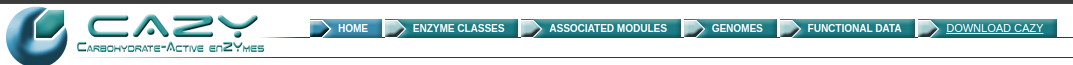

Aparte de consultar directamente la proteína en la que estemos interesados, podemos analizar este conjunto de datos descargándolas desde la página web. En este fichero podemos encontrar varías columnas con información diversa.

* **Primera columna**: Nombre de la clase de CAZyme, seguido con número de la familia a la cual pertenece
* **Segunda columna**: tipo de organismo donde se ha encontrado (Eukariota, bacteria...)
* **Tercera columna**: Organizme exacto donde se ha encontrado
* **Siguientes columnas**: Número de clasificación y en qué bases de datos se pueden encontrar.

Descargaréis un archivo denominado **cazy_fecha_*Aspergillus.txt* en que por motivos de medida, se ha dejado solo la información por los organismos Aspergillus.

In [ ]:
# Ejecutad primero esta celda pàra descargar el fichero
!wget -nc https://gitlab.uoclabs.uoc.es/prog_bioinf/data/-/raw/master/Unidad3/cazy_data_Aspergillus.txt --no-check-certificate

--2024-04-15 21:03:38--  https://gitlab.uoclabs.uoc.es/prog_bioinf/data/-/raw/master/Unidad3/cazy_data_Aspergillus.txt
Resolving gitlab.uoclabs.uoc.es (gitlab.uoclabs.uoc.es)... 18.201.253.30
Connecting to gitlab.uoclabs.uoc.es (gitlab.uoclabs.uoc.es)|18.201.253.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2879244 (2.7M) [text/plain]
Saving to: ‘cazy_data_Aspergillus.txt’

cazy_data_Aspergill 100%[===================>]   2.75M  1.61MB/s    in 1.7s    

2024-04-15 21:03:40 (1.61 MB/s) - ‘cazy_data_Aspergillus.txt’ saved [2879244/2879244]



En este ejercicio tendremos que crear dos funciones en que las suyas características tienen que ser las siguientes:
* **es_digit()**: Creáis una función en que la variable de entrada se puede corresponder a un texto en que hay letras y números y tiene que devolver solo las letras en una sola variable en formato de string.
* **clasifica_classes_CAZymes()**: Creáis una función en que la variable de entrada sea un fichero de texto descargado de la base de datos CAZy y que clasifique en un diccionario, las clases de CAZymes que hay en aquel fichero y sus valores se corresponden a la cantidad existente por cada clase.

Finalmente, feudo un gráfico de diagrama de sectores (o pie chart en ángulos) en que se vean los porcentajes para cada clase, tal y como se ve en la siguiente figura.


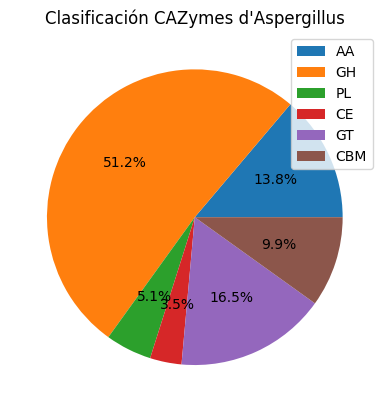

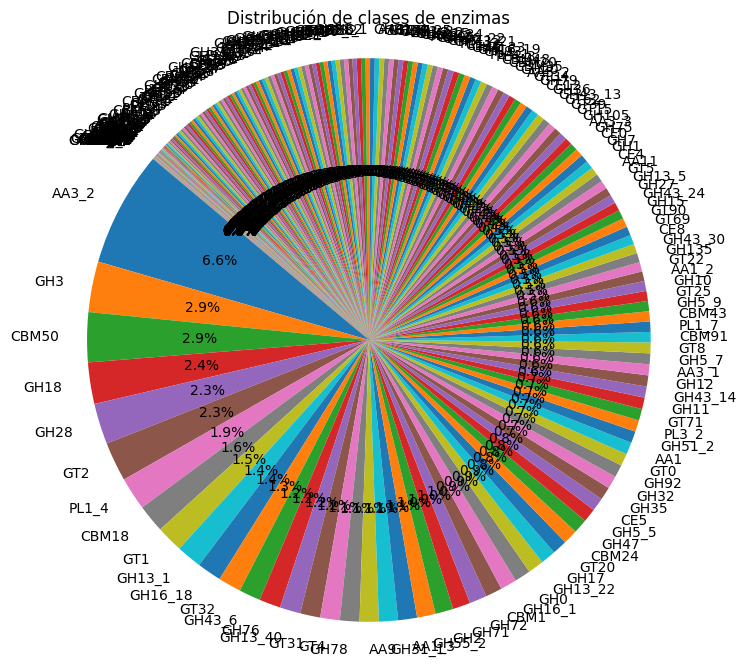

In [47]:
# para poder visualizar el gráàfico en este notebook
%matplotlib inline

# importamos los módulos necessarios
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def es_digit(data):
    # Función que encuentra si un valor de un string es un digito o no, y solamente develve
    # los valores correspondientes a las letras
    #RESPUESTA
    
    # Inicializar una cadena vacía para almacenar los dígitos encontrados
    caracteres = ""

    # Iterar sobre cada carácter en la cadena de entrada
    for caracter in data:
        # Verificar si el carácter es un dígito
        if caracter.isdigit() == False:
            # Si es un dígito, agregarlo a la cadena de dígitos
            caracteres += caracter

    # Devolver la cadena que contiene solo los dígitos encontrados
    return caracteres

def clasifica_classes_CAZymes(filename):
  # Función en que creamos un diccionario en que las keys sueño el tipo de clases
  # que pueden llegar a existir por los CAZymes y los valores se corresponde a la
  # cantidad existente de estas clases.
    # Define column names
    column_names = ['Clase', 'Tipo', 'Organismo', 'Class_number']
    
    
    # Cargar los datos sin especificar los nombres de las columnas
    df = pd.read_csv(filename, sep='\t', header=None)
    
    # Eliminar la última columna
    df.drop(df.columns[-1], axis=1, inplace=True)
    
    # Renombrar las primeras cuatro columnas
    df.columns = column_names
    
    # Crear diccionario con el contaje de cada clase
    class_counts = df['Clase'].value_counts().to_dict()
    return class_counts

filename = 'cazy_data_Aspergillus.txt'
dic_counts = clasifica_classes_CAZymes(filename)
# Extraer las claves y los valores del diccionario
clases = list(dic_counts.keys())
recuentos = list(dic_counts.values())

# Crear un gráfico circular
plt.figure(figsize=(8, 8))
plt.pie(recuentos, labels=clases, autopct='%1.1f%%', startangle=140)

# Añadir título
plt.title('Distribución de clases de enzimas')

# Mostrar el gráfico
plt.axis('equal')  # Mantener el gráfico circular
plt.show()

### **Ejercicios entregables**

**IMPORTANTE:** Recordad que es necesaria la línea

```python
%matplotlib inline
```
al principio de cada celdilla de código para que podáis visualizar los gráficos en este notebook.

### Ejercicio 1 **<font color="green" size="+2">MU</font>**

Representad en un único gráfico los valores de `RMSD` que obtenemos del mismo sistema durante dos réplicas (guardadas en las variables **rmsd_1** y **rmsd_2**) de dinámica molecular:

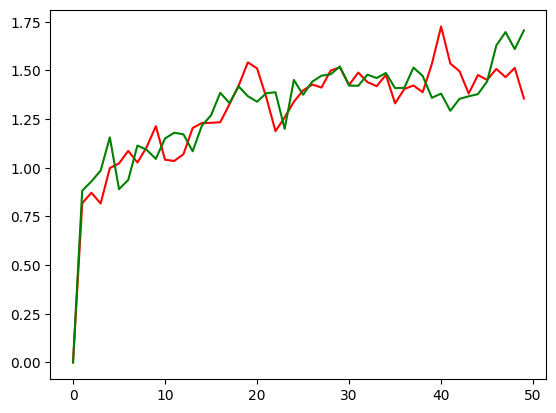

In [ ]:
# La representación debe dar una imagen como la siguiente

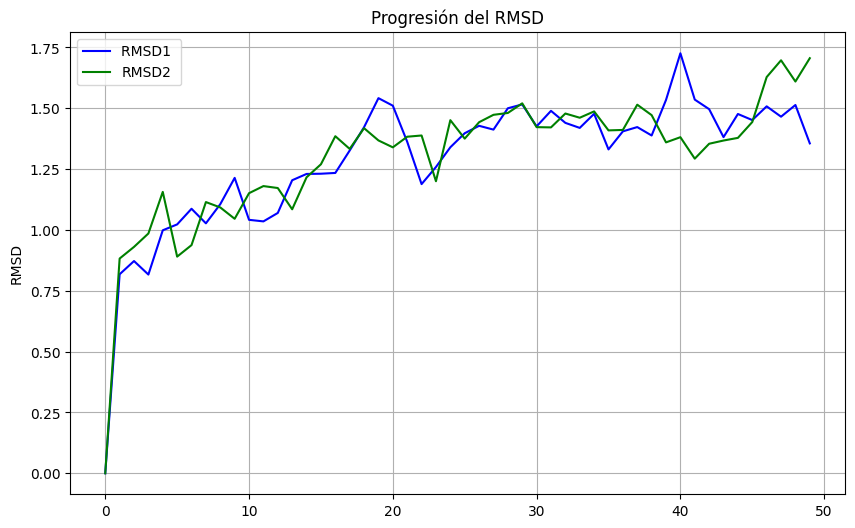

In [53]:
%matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt

rmsd_1 = [0.0, 0.8179, 0.8722, 0.8167, 0.9986, 1.0228, 1.0871, 1.0272, 1.106, 1.214, 1.0416, 1.0352, 1.0699, 1.2043, 1.2302, 1.2311, 1.2343, 1.3265, 1.4224, 1.5417, 1.5107, 1.3624, 1.1884, 1.2587, 1.3398, 1.3975, 1.428, 1.4124, 1.5001, 1.5159, 1.4257, 1.4895, 1.4401, 1.4194, 1.4773, 1.331, 1.4052, 1.4228, 1.3882, 1.5344, 1.7261, 1.5357, 1.4964, 1.3815, 1.4766, 1.4516, 1.508, 1.4655, 1.5135, 1.3558]
rmsd_2 = [0.0, 0.8825, 0.9304, 0.9855, 1.1564, 0.8904, 0.9377, 1.1146, 1.0925, 1.0459, 1.1511, 1.1803, 1.1723, 1.0849, 1.2163, 1.2699, 1.3853, 1.3331, 1.4182, 1.3679, 1.3395, 1.3832, 1.3882, 1.2002, 1.4512, 1.3753, 1.4428, 1.4732, 1.4808, 1.5204, 1.4225, 1.4215, 1.4785, 1.4612, 1.4872, 1.4092, 1.411, 1.5148, 1.4719, 1.3599, 1.3812, 1.293, 1.3543, 1.3675, 1.3784, 1.4436, 1.6283, 1.6973, 1.61, 1.7059]

# Respuesta
# Crear gráfico
plt.figure(figsize=(10, 6))
plt.plot(rmsd_1, label='RMSD1 ', color='blue')
plt.plot(rmsd_2, label='RMSD2', color='green')


plt.title('Progresión del RMSD')
plt.ylabel('RMSD')
plt.legend()
plt.grid(True)

plt.show()



### Ejercicio 2 **<font color="blue" size="+2">EG</font>**

Representa en un gráfico 3D la función `f(x,y) = 4*cos(x) + 3*sin(y)` en el intervalo `[-2(pi/2), 2(pi/2)]` (en radianes) con un step de `0.1`

Podéis consultar ejemplos de graficos 3D aquí: https://matplotlib.org/stable/plot_types/index.html

In [ ]:
# La representación debe dar una imagen como la siguiente

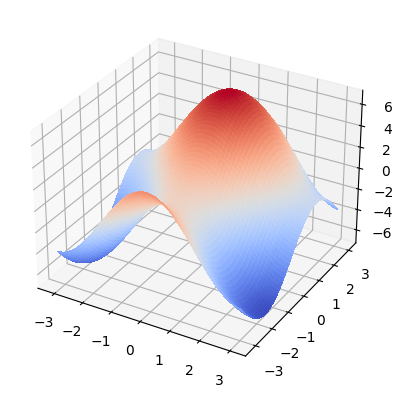

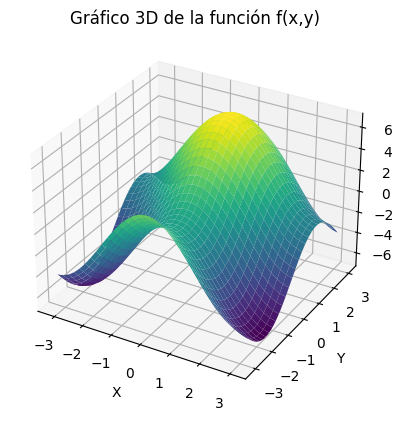

In [54]:
%matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Definir el intervalo y el paso
x = np.arange(-2*np.pi/2, 2*np.pi/2, 0.1)
y = np.arange(-2*np.pi/2, 2*np.pi/2, 0.1)

# Crear una malla de valores de x e y
X, Y = np.meshgrid(x, y)

# Calcular los valores de z según la función dada
Z = 4 * np.cos(X) + 3 * np.sin(Y)

# Crear la figura y los ejes 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Graficar la superficie 3D
ax.plot_surface(X, Y, Z, cmap='viridis')

# Añadir etiquetas de los ejes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Añadir título
plt.title('Gráfico 3D de la función f(x,y)')

# Mostrar el gráfico
plt.show()

# Respuesta

### Ejercicio 3 **<font color="blue" size="+2">EG</font>**
Representa la función que quieras de la forma que consideres. Sé creativo a la hora de escoger la función a representar y el intervalo de valores.

Podéis consultar https://matplotlib.org/stable/plot_types/index.html para inspiraros.

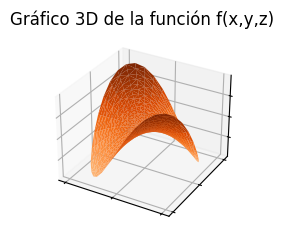

In [70]:
%matplotlib inline

#Respuesta
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cm

plt.style.use('_mpl-gallery')

n_radii = 16
n_angles = 36

# Make radii and angles spaces
radii = np.linspace(0.125, 1.0, n_radii)
angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)[..., np.newaxis]

# Convert polar (radii, angles) coords to cartesian (x, y) coords.
x = np.append(0, (radii*np.cos(angles)).flatten())
y = np.append(0, (radii*np.sin(angles)).flatten())
z = np.sin(-x*y)

# Plot

# Crear la figura y los ejes 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(x, y, z, vmin=z.min() * 2, cmap=cm.Oranges)

ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

plt.title('Gráfico 3D de la función f(x,y,z)')

plt.show()

### Ejercicio 4 **<font color="green" size="+2">MU</font>**

Dados los siguientes datos procedentes de una dinámica molecular de una proteína, representad en uno o varios gráficos los valores máximos, mínimos y medios de la distancia entre un átomo del sustrato y diferentes aminoácidos de la proteína. Representad también, el r.m.s.f correspondiente para cada aminoácido.

_El root mean square fluctuation (r.m.s.f.) es una medida numérica que mide la flexibilidad individual de diferentes partículas a lo largo de una trayectoria de dinámica molecular. Esta medida normalmente nos sirve para encontrar qué aminoácidos son los que más contribuyen en el movimiento de la proteína._

Las posiciones del vector **datos_dinamica** son las siguientes:

* Número aminoácido
* Valor máximo distancia entre sustrato y aminoácido (Å)
* Valor mínimo distancia entre sustrato y aminoácido (Å)
* Valor medio distancia entre sustrato y aminoácido (Å)
* Valor r.m.s.f. (Å)

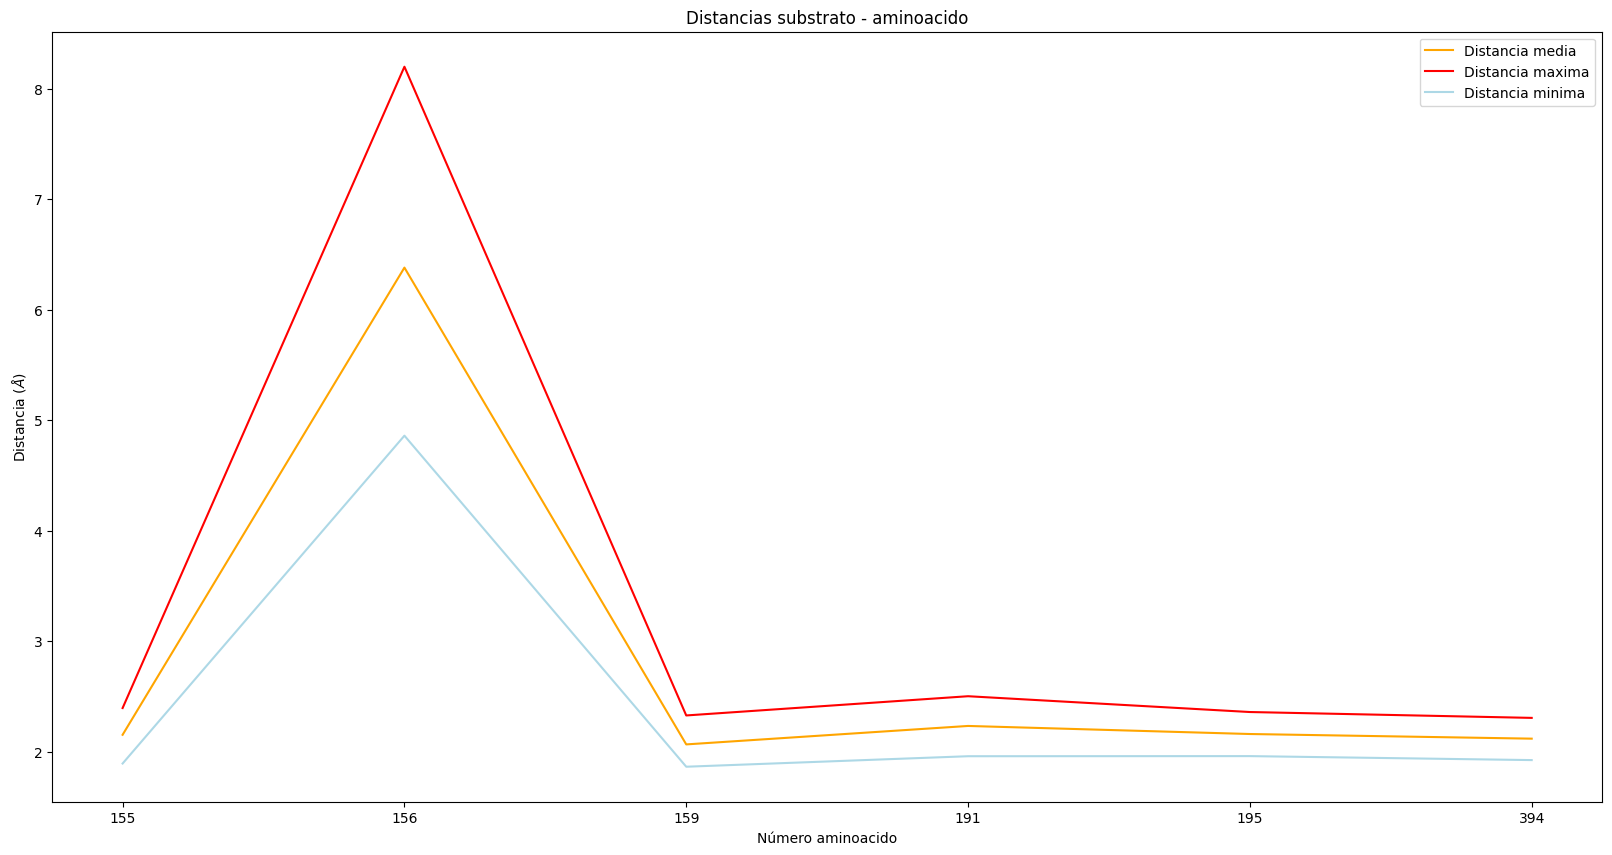

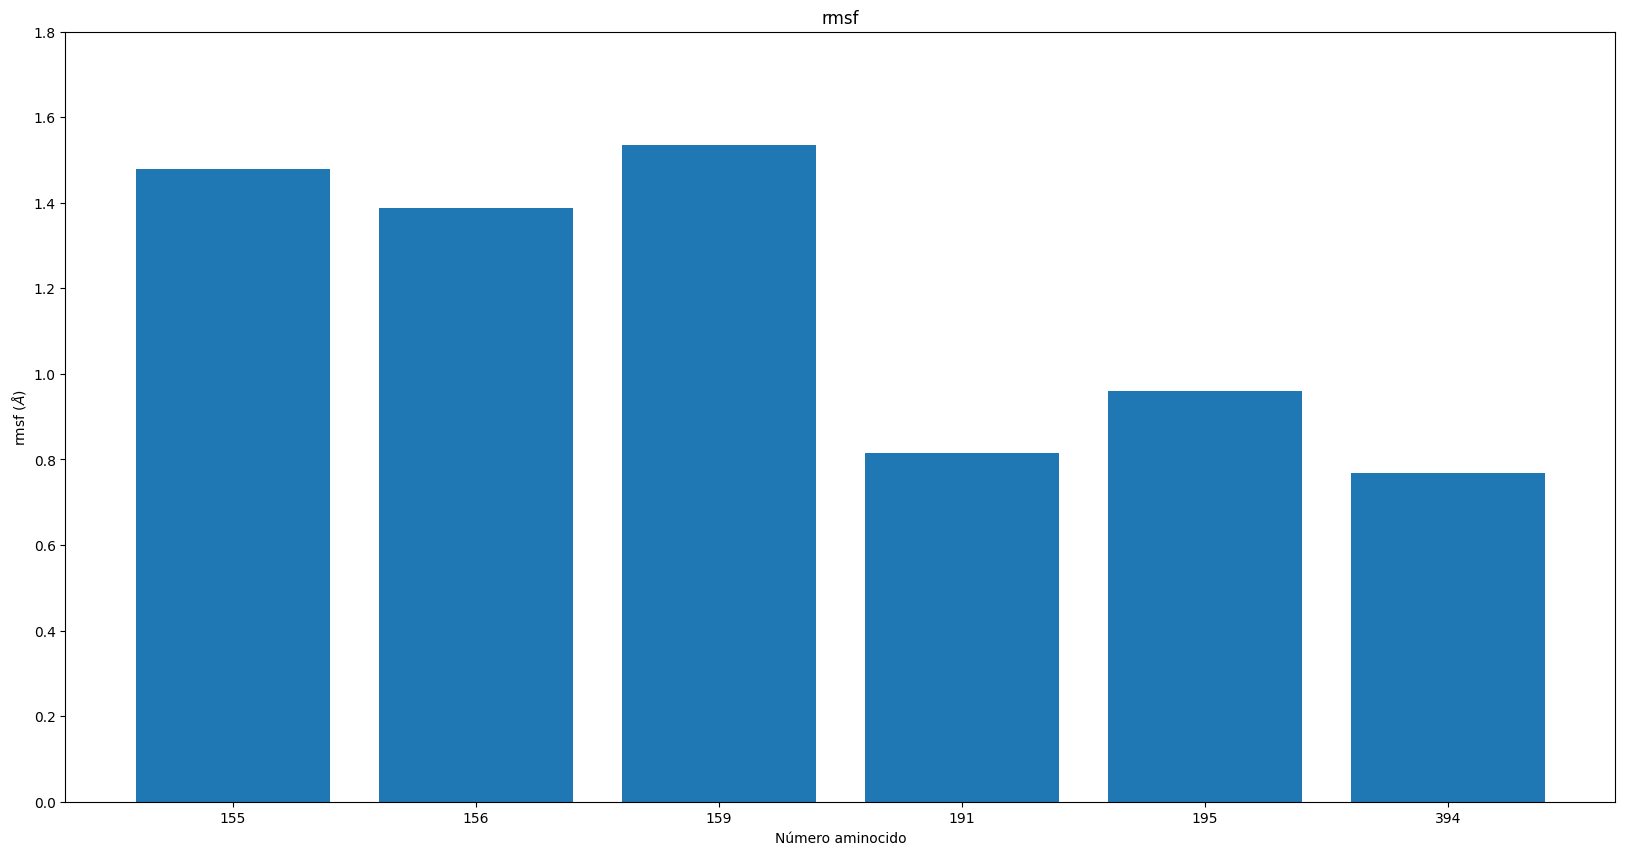

In [ ]:
#La representación debe devolver gráficos similares a los siguientes

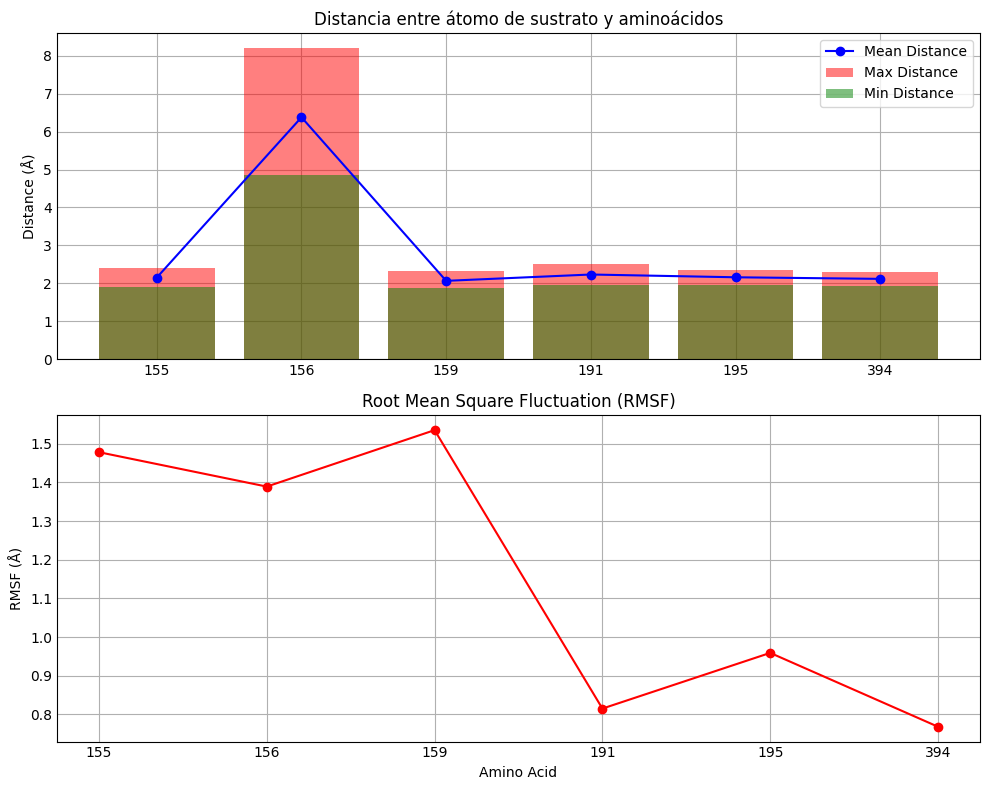

In [79]:
from matplotlib import figure
%matplotlib inline
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

datos_dinamica = [["155", 2.394, 1.892, 2.152, 1.478],
                  ["156", 8.198, 4.859, 6.380, 1.389],
                  ["159", 2.327, 1.863, 2.065, 1.535],
                  ["191", 2.501, 1.958, 2.232, 0.815],
                  ["195", 2.358, 1.959, 2.159, 0.959],
                  ["394", 2.305, 1.923, 2.117, 0.768]]

# Respuesta

# Assignamos vectores
aminoacids = [data[0] for data in datos_dinamica]
max_distances = [data[1] for data in datos_dinamica]
min_distances = [data[2] for data in datos_dinamica]
mean_distances = [data[3] for data in datos_dinamica]
rmsf_values = [data[4] for data in datos_dinamica]

# definimos graficos
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Grafico de distancia
axs[0].bar(aminoacids, max_distances, label='Max Distance', color='red', alpha=0.5)
axs[0].bar(aminoacids, min_distances, label='Min Distance', color='green', alpha=0.5)
axs[0].plot(aminoacids, mean_distances, marker='o', label='Mean Distance', color='blue')
axs[0].set_ylabel('Distance (Å)')
axs[0].set_title('Distancia entre átomo de sustrato y aminoácidos')
axs[0].legend()

# grafico RMSF
axs[1].plot(aminoacids, rmsf_values, marker='o', color='red')
axs[1].set_ylabel('RMSF (Å)')
axs[1].set_xlabel('Amino Acid')
axs[1].set_title('Root Mean Square Fluctuation (RMSF)')

# Adjust layout
plt.tight_layout()
plt.show()

**Autoria**

Autores/as que han participado colectivamente en esta obra:


*   Pau Andrio Balado
*   Brian Jiménez García
*   Melchor Sanchez Martinez
*   Alba Nin Hill

**Fecha de creación**


*   Ultima modificación: Abril 2024